# Template: Fetch Data From an API

Fetches trailing-12-month daily precipitation for NYC from the [Open-Meteo Historical Weather API](https://open-meteo.com/) (no key required), caches the raw pull, aggregates it to weekly totals, and charts it. Copy this folder as a starting point for a new API-fetch analysis and swap in the relevant source/params.

In [1]:
from datetime import date, timedelta
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from shared.api import get
from shared.plots.style import apply_theme, add_source_footnote

apply_theme()

## Fetch raw data

In [2]:
NYC_LAT, NYC_LON = 40.7128, -74.0060

end_date = date.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365)

response = get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": NYC_LAT,
        "longitude": NYC_LON,
        "start_date": start_date.isoformat(),
        "end_date": end_date.isoformat(),
        "daily": "precipitation_sum",
        "timezone": "America/New_York",
    },
)

daily = pd.DataFrame(
    {
        "date": response["daily"]["time"],
        "precipitation_mm": response["daily"]["precipitation_sum"],
    }
)
daily["date"] = pd.to_datetime(daily["date"])
daily.head()

,date,precipitation_mm
0,2025-08-29,0.0
1,2025-08-30,0.0
2,2025-08-31,0.0
3,2025-09-01,0.0
4,2025-09-02,0.0


In [3]:
range_label = f"{start_date.isoformat()}_{end_date.isoformat()}"
raw_dir = Path(f"data/raw/open_meteo_precipitation/{range_label}")
raw_dir.mkdir(parents=True, exist_ok=True)
daily.to_csv(raw_dir / "data.csv", index=False)

## Process: weekly totals

In [4]:
daily["week_start"] = daily["date"].dt.to_period("W-SUN").dt.start_time
weekly = (
    daily.groupby("week_start", as_index=False)["precipitation_mm"]
    .sum()
    .rename(columns={"precipitation_mm": "weekly_precipitation_mm"})
)

processed_dir = Path(f"data/processed/open_meteo_precipitation/{range_label}")
processed_dir.mkdir(parents=True, exist_ok=True)
weekly.to_csv(processed_dir / "data.csv", index=False)
weekly.tail()

,week_start,weekly_precipitation_mm
48,2026-07-27,96.9
49,2026-08-03,47.3
50,2026-08-10,31.5
51,2026-08-17,52.8
52,2026-08-24,7.8


## Chart: weekly precipitation

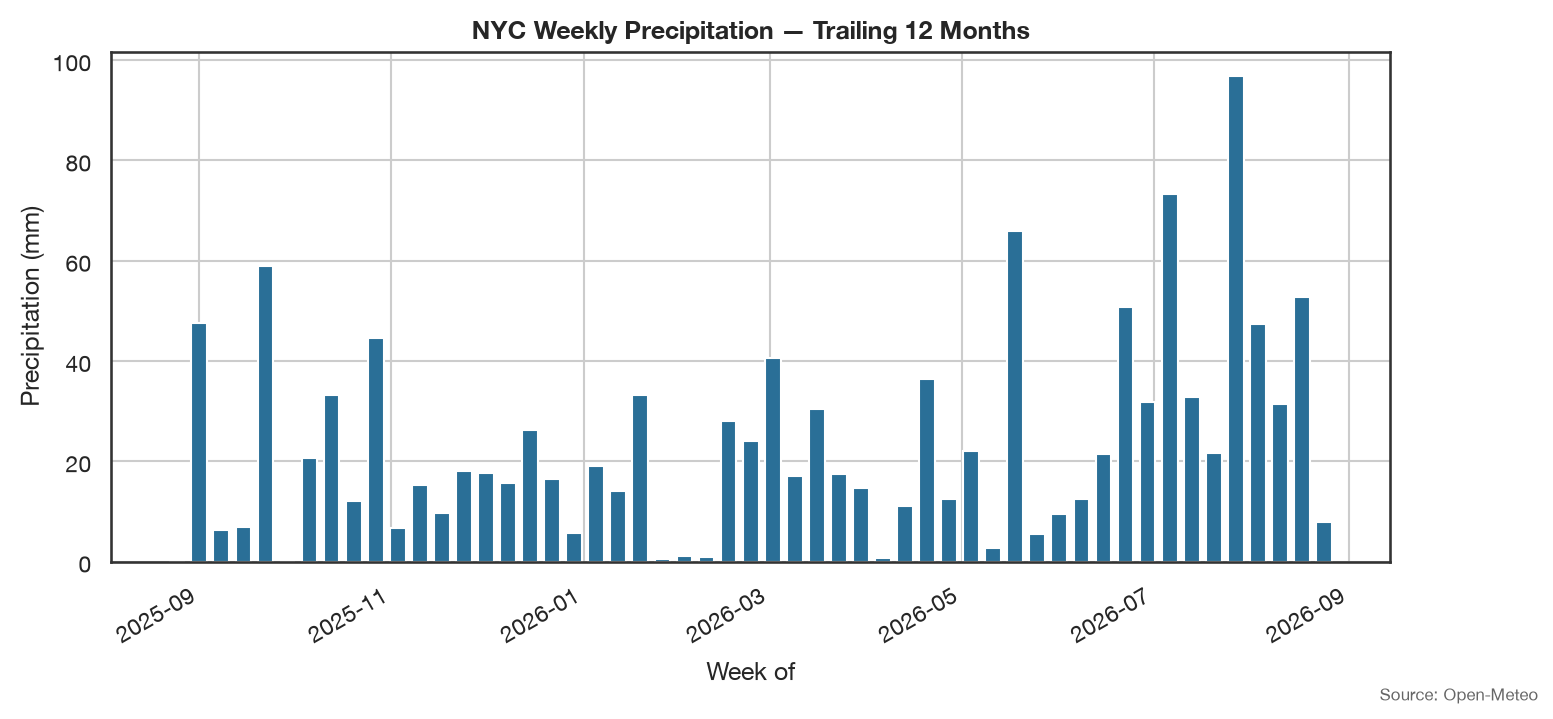

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(weekly["week_start"], weekly["weekly_precipitation_mm"], width=5, color="#2A6F97")

ax.set_title("NYC Weekly Precipitation \u2014 Trailing 12 Months")
ax.set_xlabel("Week of")
ax.set_ylabel("Precipitation (mm)")
fig.autofmt_xdate()

add_source_footnote(fig, "Open-Meteo")

output_dir = Path(f"outputs/{range_label}/charts")
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "weekly_precipitation.png", bbox_inches="tight")
plt.show()